<a href="https://colab.research.google.com/github/antoniocesar-amf/ppcompann/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
base_url = "https://ossci-datasets.s3.amazonaws.com/mnist/"
files = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz"
]

for fname in files:
  !wget -q {base_url + fname}
  print(fname)

train-images-idx3-ubyte.gz
train-labels-idx1-ubyte.gz
t10k-images-idx3-ubyte.gz
t10k-labels-idx1-ubyte.gz


In [2]:
import gzip
import numpy as np

def load_idx(filename):
  with gzip.open(filename, 'rb') as f:
    data = f.read()

  n_dims = data[3]

  dims = []
  for i in range(n_dims):
    begin = 4 + i * 4
    end = begin + 4
    dims.append(int.from_bytes(data[begin:end], byteorder='big'))

  offset = 4 + 4 * n_dims
  X = np.frombuffer(data, dtype=np.uint8, offset=offset)
  X = X.reshape(dims)

  return X

train_images = load_idx("train-images-idx3-ubyte.gz")
train_labels = load_idx("train-labels-idx1-ubyte.gz")
test_images = load_idx("t10k-images-idx3-ubyte.gz")
test_labels = load_idx("t10k-labels-idx1-ubyte.gz")

print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


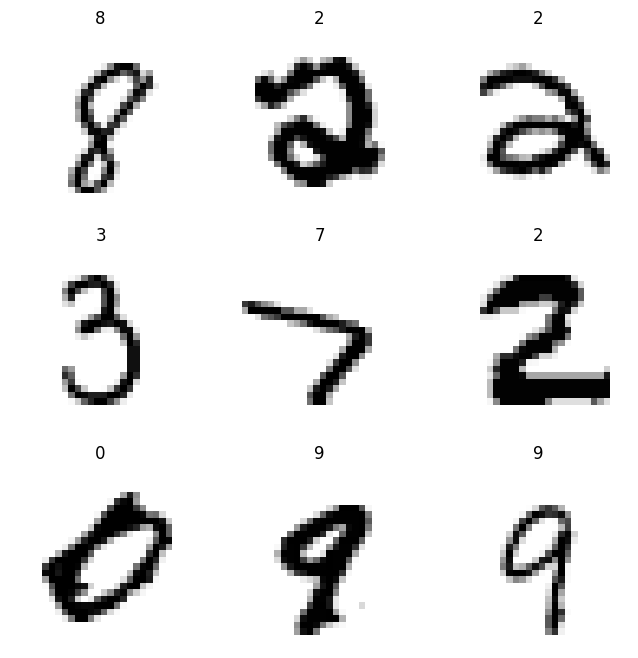

In [3]:
import matplotlib.pyplot as plt

samples = np.random.randint(0, train_images.shape[0], 9)

plt.figure(figsize=(8,8))
for i, sample in enumerate(samples):
  plt.subplot(3, 3, i+1)
  plt.imshow(train_images[sample], cmap=plt.cm.binary)
  plt.title(train_labels[sample])
  plt.axis('off')
plt.show()

In [6]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def KerasCNN2D(input_shape, num_classes):
  inputs = keras.Input(shape=input_shape)
  x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(inputs)
  x = layers.MaxPooling2D(pool_size=2)(x)
  x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
  x = layers.MaxPooling2D(pool_size=2)(x)
  x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
  x = layers.Flatten()(x)
  outputs = layers.Dense(num_classes, activation="softmax")(x)
  return keras.Model(inputs=inputs, outputs=outputs)

class KerasWrappedNN(BaseEstimator, ClassifierMixin):
  def __init__(self, epochs=5, batch_size=128, model_fabric=KerasCNN2D):
    self.epochs = epochs
    self.batch_size = batch_size
    self.model_fabric = model_fabric

  def fit(self, X, y):
    self.labels, ids = np.unique(y, return_inverse=True)
    y_hot = keras.utils.to_categorical(ids, len(self.labels))
    self.model = self.model_fabric(X.shape[1:], num_classes=len(np.unique(y)))
    self.model.compile(
        optimizer="rmsprop",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    self.model.fit(
        X, y_hot,
        epochs=self.epochs,
        batch_size=self.batch_size
    )
    return self

  def predict(self, X):
    y_pred = self.model.predict(X)
    return self.labels[np.argmax(y_pred, axis=1)]

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score

class Divide255(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    return X / 255.0

class Shape2Keras(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    return X.reshape((-1, 28, 28, 1))

pipeline = Pipeline([
  ('scaler', Divide255()),
  ('shape', Shape2Keras()),
  ('model', KerasWrappedNN(model_fabric=KerasCNN2D))
])

pipeline.fit(train_images, train_labels)
y_pred = pipeline.predict(test_images)
print(accuracy_score(test_labels, y_pred))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 116ms/step - accuracy: 0.9344 - loss: 0.2130
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 112ms/step - accuracy: 0.9830 - loss: 0.0545
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - accuracy: 0.9882 - loss: 0.0370
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 112ms/step - accuracy: 0.9911 - loss: 0.0279
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - accuracy: 0.9934 - loss: 0.0215
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
0.9905


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
